In [2]:
import sys
import os

# 获取当前目录的绝对路径，并添加上一级目录到 sys.path
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

In [3]:
from StochasticVolatilityModel import StochasticVolatilityModel
from LambdaNetwork import LambdaNetwork
from lnSRE_Equation import lnSRE_Equation
from DeepLnSRESolver import DeepLnSRESolver

from DeepBSDEBacktestEngine_lnSRE import BacktestEngine
from DeepBSDE_Strategy_LogSpace import DeepBSDE_Strategy_LogSpace

In [7]:
import torch
import numpy as np
import math

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BACKTEST_FILE = 'SP500_ETFs_data.csv' 
RF = 0.02
DT = 1/252
T_HORIZON = 1.0 
 
lambda_net = LambdaNetwork(
    num_steps=int(T_HORIZON / DT),
    state_dim=5,
    lambda_dim=14,
    hidden_layers=[20, 20] 
).to(torch.float64)


ln_sre_eq_dummy = lnSRE_Equation({'r': RF}, device=DEVICE)

solver = DeepLnSRESolver({'r': RF}, lambda_net, ln_sre_eq_dummy, device=DEVICE)

MODEL_PATH = './sre_deepbsde_model_step5.pt'
historical_params = solver.load_model(MODEL_PATH)

check_p0 = solver.P0.item()
p0_physical = math.exp(check_p0)  




ln_sre_eq_real = lnSRE_Equation(historical_params, device=DEVICE)
input_q0 = np.exp(-RF * T_HORIZON)



>>> [Model] Loaded: ./sre_deepbsde_model_step5.pt
    Epoch: 3010 | check_P0: -1.272824 | P0_Exp: 0.280040


Init
[Engine] Data Loaded. Rows: 4021

[Start]
 Data Start Date : 2020-01-02
 Strategy Window : 20
 Allow Leverage  : False
----------------------------------------

[Metrics]
Strategy        | Return   | Vol      | Sharpe   | Sortino  | Calmar   | MDD      | RT     | MES(5%) 
-----------------------------------------------------------------------------------------------------
Affine_6.0%     |    5.60% |   18.24% |     0.31 |     0.42 |     0.35 |  -16.13% |    161 |   -0.99%
EW              |    3.69% |   58.57% |     0.06 |     0.09 |     0.07 |  -52.56% |    215 |   -9.55%
IV              |    5.85% |   44.45% |     0.13 |     0.17 |     0.13 |  -43.68% |    220 |   -7.18%
GMV             |   21.88% |   17.09% |     1.28 |     1.86 |     2.62 |   -8.35% |     80 |   -1.20%


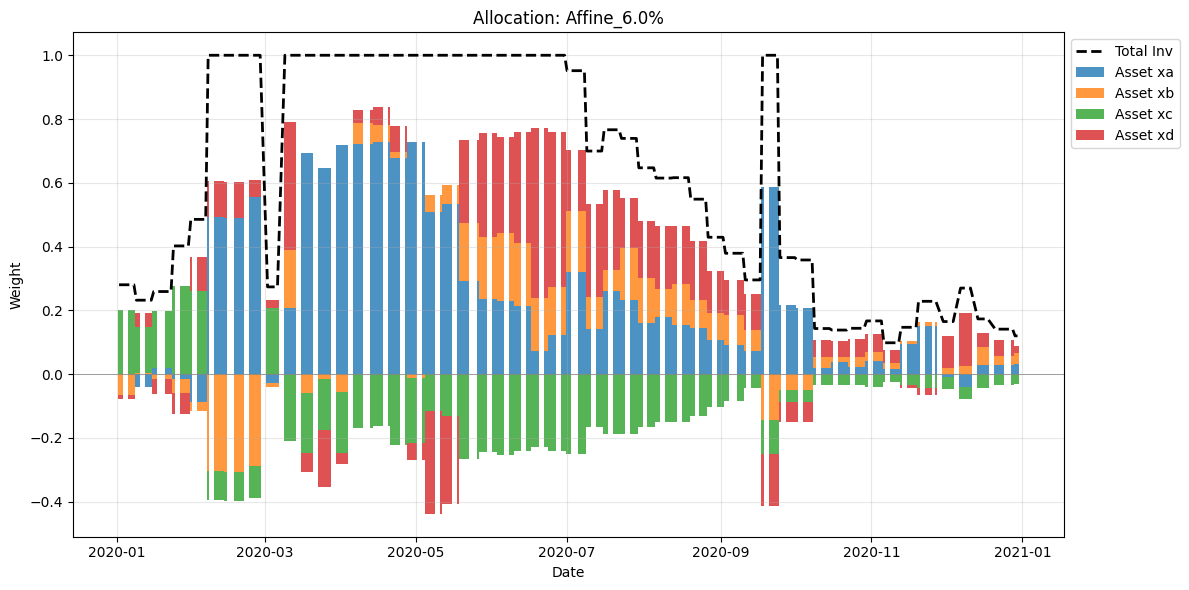

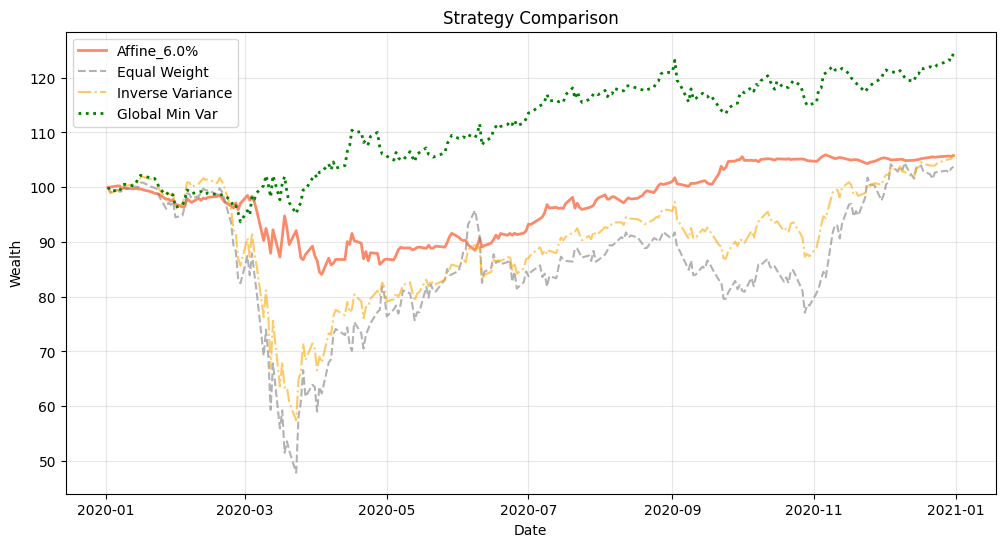

In [12]:
 
logspace_strategy = DeepBSDE_Strategy_LogSpace(
    initial_check_p0=check_p0,     
    q0=input_q0,
    model_params=historical_params,
    r_f=RF,
    dt=DT,
    T_horizon=T_HORIZON,
    lambda_net=solver.lambda_net,   
    sre_eq=ln_sre_eq_real,          
    device=DEVICE,
)
 
bt_engine = BacktestEngine(assets=['xa', 'xb', 'xc', 'xd'])
bt_engine.load_data(BACKTEST_FILE)
 
targets = [0.06] # 4% 目标收益
 
results = bt_engine.run_backtest(
    strategy=logspace_strategy,    
    start_date='2020-01-01',
    end_date='2020-12-31',
    target_return=0.06,
    initial_capital=100.0,
    rebalance_period=5,
    strategy_window=20,
    allow_leverage=False
)

 
target_key = f'Affine_{targets[0]:.1%}'
bt_engine.plot_asset_allocation(target_key)
 
bt_engine.plot_comparison()

In [13]:
bt_engine.export_trades_to_csv('DeepBSDE_2020_6%.csv')


[Export]
 Interval : 2020-01-02 -> 2020-12-31
[Saved] DeepBSDE_2020_6%.csv
